# 04 - Phân tích văn bản

Người làm: Nguyễn Huy Sơn

Do bất cân xứng thông tin, những gì người mua biết về tình trạng xe phần lớn đến từ phần chữ người bán viết trong tin đăng. Notebook này phân tích phần chữ đó để trả lời 2 câu hỏi:

1. Người bán hay cam kết những gì về chiếc xe? (Word Cloud các cụm từ hay gặp)
2. Có thể biến các cam kết đó thành đặc trưng cho mô hình định giá không? (tạo biến cờ 0/1, lưu ra `data/processed/text_flags.csv` cho notebook 05)

Đầu vào: `data/processed/cars_cleaned.csv` (notebook 02) và `data/raw/descriptions.csv` (notebook 01).

In [1]:
import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

# tắt bớt cảnh báo khi import underthesea
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from underthesea import word_tokenize

# tìm thư mục gốc của project để chạy được trên máy của cả nhóm
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

CLEAN_PATH = ROOT / "data" / "processed" / "cars_cleaned.csv"
DESC_PATH = ROOT / "data" / "raw" / "descriptions.csv"
FLAGS_PATH = ROOT / "data" / "processed" / "text_flags.csv"

## 1. Dữ liệu văn bản

Tiêu đề (`subject`) thì tin nào cũng có, còn mô tả chi tiết được cào bổ sung ở notebook 01 nên chỉ có ở một phần các tin. Nối mô tả vào dữ liệu đã làm sạch theo `list_id`:

In [2]:
df = pd.read_csv(CLEAN_PATH, low_memory=False)
mo_ta = pd.read_csv(DESC_PATH)

# nối trái để giữ đủ các tin, tin nào không có mô tả thì để trống
df = df.merge(mo_ta, on="list_id", how="left")
df["co_mo_ta"] = df["description"].notna().astype(int)

print("Số tin:", len(df))
print(f"Có mô tả: {df['co_mo_ta'].sum()} tin ({df['co_mo_ta'].mean():.1%})")
print(f"Độ dài trung bình: tiêu đề {df['subject'].str.len().mean():.0f} ký tự, mô tả {df['description'].str.len().mean():.0f} ký tự")

Số tin: 13520
Có mô tả: 9501 tin (70.3%)
Độ dài trung bình: tiêu đề 37 ký tự, mô tả 368 ký tự


Khoảng 70% tin có mô tả, số còn lại đã bị gỡ khỏi Chợ Tốt lúc cào bổ sung nên chỉ còn tiêu đề. Mô tả dài hơn tiêu đề khoảng 10 lần nên chứa nhiều thông tin hơn hẳn.

Nhóm ghép tiêu đề và mô tả thành một đoạn văn bản cho mỗi tin, tin không có mô tả thì chỉ có tiêu đề. Cột `co_mo_ta` được giữ lại để biết tin nào chỉ có tiêu đề, vì các tin này ít chữ nên sẽ ít khi bắt được từ khóa.

In [3]:
df["van_ban"] = df["subject"] + ". " + df["description"].fillna("")

## 2. Tiền xử lý

Văn bản tin đăng khá lộn xộn: nhiều emoji, ký hiệu trang trí, chữ in đậm kiểu 𝗚𝗶𝗮́ (là ký tự Unicode đặc biệt chứ không phải chữ thường), số điện thoại, viết tắt "ko" thay cho "không". Các bước xử lý:

1. Chuẩn hóa Unicode bằng NFKC để đưa các kiểu chữ đặc biệt về chữ bình thường, rồi chuyển về chữ thường.
2. Bỏ link, thống nhất một số cách viết: "ko", "k" -> "không"; "1 chủ" -> "một chủ"; "thuỷ" -> "thủy".
3. Bỏ số, emoji và dấu câu, chỉ giữ lại chữ.
4. Tách từ tiếng Việt bằng thư viện `underthesea`. Từ ghép được nối bằng dấu `_`, ví dụ "đâm_đụng", "bảo_dưỡng".

In [4]:
def lam_sach(text):
    text = unicodedata.normalize("NFKC", text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\b(ko|k|hok|khong)\b", "không", text)
    text = re.sub(r"\b1 chủ\b", "một chủ", text)
    text = text.replace("thuỷ", "thủy")
    # chỉ giữ chữ, bỏ số, dấu câu, emoji
    text = re.sub(r"[^\w\s]|\d|_", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["van_ban_sach"] = df["van_ban"].apply(lam_sach)

# tách từ, chạy mất khoảng 20-30 giây
df["tu"] = df["van_ban_sach"].apply(lambda s: word_tokenize(s, format="text").split())

In [5]:
# xem thử 1 tin trước và sau khi xử lý
vi_du = df[df["description"].str.contains("keo chỉ", na=False)].iloc[0]
print("Trước:")
print(vi_du["van_ban"][:300])
print("\nSau khi làm sạch và tách từ:")
print(" ".join(vi_du["tu"])[:300])

Trước:
Suzuki Swift 2019 GL 1.2 AT -xe cá nhân. Swift GL 1.2AT sx 2019 nhập khẩu, một chủ đi 8v km xe giữ gìn rất đẹp,bảo dưỡng hãng, cam kết:
- xe không bị đâm đụng ngập nước, thủy kích 
- keo chỉ khung gầm còn zin và chắc chắn 
- bảo hành máy và hộp số cho khách hàng nguyên zin 
-  hồ sơ pháp lý nguồ

Sau khi làm sạch và tách từ:
suzuki swift gl at xe cá_nhân swift gl at sx nhập_khẩu một chủ đi v km xe giữ_gìn rất đẹp bảo_dưỡng hãng cam_kết xe không bị đâm đụng ngập nước thủy_kích keo chỉ khung gầm còn zin và chắc_chắn bảo_hành máy và hộp_số cho khách_hàng nguyên_zin hồ_sơ pháp_lý nguồn_gốc rõ_ràng sang_tên cho người mua tro


## 3. Word Cloud các cụm từ hay gặp

Các cam kết trong tin thường là một cụm vài từ ("không đâm đụng", "keo chỉ zin", "một chủ từ đầu"), nếu đếm từng từ riêng lẻ thì sẽ mất nghĩa. Vì vậy nhóm đếm các cụm 2-4 từ liên tiếp, mỗi cụm chỉ tính 1 lần trong một tin, tức là đếm số tin có nhắc tới cụm đó. Một số quy tắc lọc:

- Cụm không được bắt đầu hoặc kết thúc bằng từ dừng (và, của, có, xe, bán, giá, liên hệ...), tên màu, đơn vị (km, odo) hay tên hãng, tên dòng xe.
- Chữ "không" chỉ được đứng đầu cụm. Nhờ vậy giữ được "không đâm đụng", "không ngập nước" mà bỏ được các mảnh như "đâm đụng không".
- Nếu một cụm ngắn phần lớn nằm trong một cụm dài hơn (cụm dài chiếm từ 50% số lần xuất hiện trở lên) thì chỉ giữ cụm dài, ví dụ giữ "không ngập nước" và bỏ "ngập nước".

In [6]:
tu_dung = set("""
và của có là các cho với được đã đang sẽ thì mà này nên rất lại ra vào nữa như để đi đến từ ở tại trên dưới
những cũng còn vẫn hay hoặc nếu khi bị do vì nhé ạ à em anh chị mình bạn ai gì nào đó đây thế rồi luôn chỉ
đều theo về qua hơn nhất quá lắm thêm cùng mới tất_cả
xe bán cần_bán giá mua liên_hệ xem năm đời bản màu chiếc chỗ km odo vạn v tp hcm hà_nội
trắng đen đỏ xám bạc xanh vàng nâu cát
""".split())

# thêm tên hãng và tên dòng xe vào từ dừng (toyota, vios, ranger...)
ten_xe = (df["carbrand_name"] + " " + df["carmodel_name"]).str.lower().str.cat(sep=" ").split()
tu_dung.update(ten_xe)


def lay_cum_tu(tu):
    cum = set()
    for n in (2, 3, 4):
        for i in range(len(tu) - n + 1):
            c = tu[i:i + n]
            # cụm kết thúc bằng "bao" thường bị cắt dở (bao test, bao check)
            if c[0] in tu_dung or c[-1] in tu_dung or c[-1] == "bao" or "không" in c[1:]:
                continue
            cum.add(" ".join(c).replace("_", " "))
    return cum


dem = Counter()
for tu in df["tu"]:
    dem.update(lay_cum_tu(tu))

top = dict(dem.most_common(600))

# bỏ cụm ngắn nếu cụm dài hơn chứa nó chiếm từ 50% số lần xuất hiện trở lên
cum_giu = {}
for c, so in top.items():
    nam_trong_cum_dai = any(d != c and f" {c} " in f" {d} " and top[d] >= 0.5 * so for d in top)
    if not nam_trong_cum_dai:
        cum_giu[c] = so

print("Số cụm còn lại:", len(cum_giu))

Số cụm còn lại: 384


Trong các cụm còn lại có nhiều cụm nói về tiện nghi (ghế da, cửa sổ trời, camera hành trình) hoặc thủ tục mua bán (hỗ trợ trả góp, sang tên). Bài toán của dự án là người mua không biết rõ tình trạng thật của xe, nên Word Cloud chỉ giữ các cụm nói về tình trạng và lịch sử xe, tức là cụm có chứa các từ như zin, đâm đụng, ngập, thủy kích, chủ, bảo dưỡng, test, lỗi...

In [7]:
# từ khóa về tình trạng / lịch sử xe
tu_khoa = ["zin", "nguyên bản", "đâm đụng", "ngập", "thủy kích", "tai nạn", "va chạm", "tua", "đồng hồ",
           "chủ", "lịch sử", "bảo dưỡng", "test", "check", "kiểm định", "bảo hành", "keo", "sơn",
           "khung gầm", "lỗi"]

cum_tinh_trang = {c: so for c, so in cum_giu.items() if any(f" {k} " in f" {c} " for k in tu_khoa)}
cum_khac = [c for c in cum_giu if c not in cum_tinh_trang]

print("Số cụm về tình trạng xe:", len(cum_tinh_trang))
print("Một số cụm hay gặp nhưng không thuộc nhóm này:", ", ".join(cum_khac[:12]))

Số cụm về tình trạng xe: 87
Một số cụm hay gặp nhưng không thuộc nhóm này: số sàn, máy số, phim cách, tiết kiệm nhiên liệu, ghế da, giữ gìn cẩn thận, vận hành êm ái, hỗ trợ trả góp, nhanh gọn, nội thất rộng rãi, cửa sổ trời, máy dầu


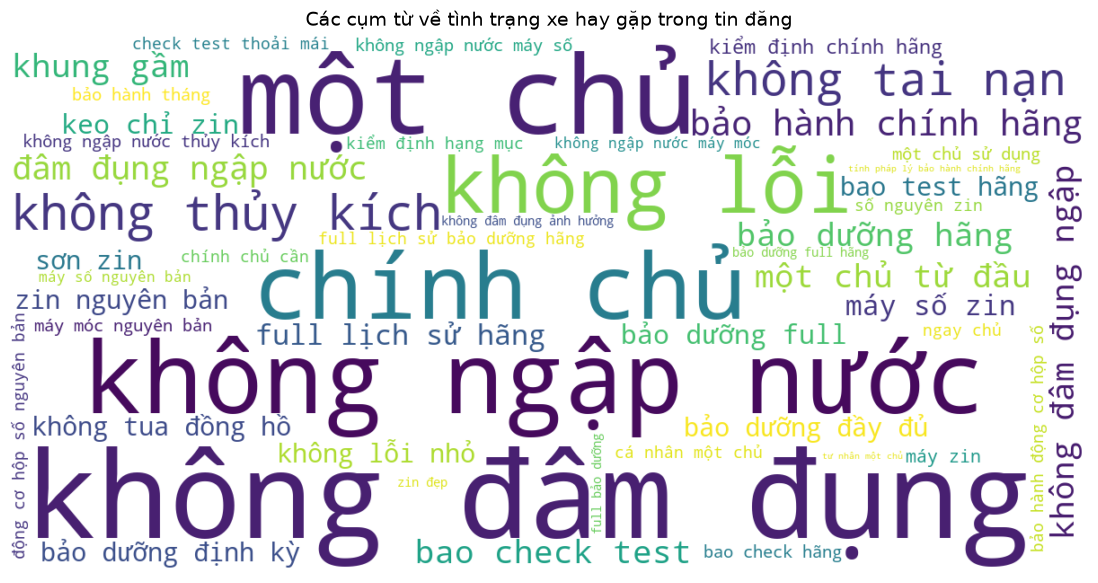

In [8]:
wc = WordCloud(width=1200, height=600, background_color="white", max_words=50, random_state=42)
wc.generate_from_frequencies(dict(list(cum_tinh_trang.items())[:50]))

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Các cụm từ về tình trạng xe hay gặp trong tin đăng", fontsize=14)
plt.show()

In [9]:
bang = pd.DataFrame(list(cum_tinh_trang.items())[:15], columns=["Cụm từ", "Số tin"])
bang["% tin"] = (bang["Số tin"] / len(df) * 100).round(1)
bang

,Cụm từ,Số tin,% tin
0,không đâm đụng,2058,15.2
1,một chủ,1646,12.2
2,không ngập nước,1381,10.2
3,chính chủ,1121,8.3
4,không lỗi,771,5.7
5,không thủy kích,569,4.2
6,không tai nạn,516,3.8
7,bảo hành chính hãng,486,3.6
8,đâm đụng ngập nước,425,3.1
9,bảo dưỡng hãng,402,3.0


In [10]:
# các cụm nêu trong kế hoạch dự án
for c in ["keo chỉ zin", "bao test hãng", "một chủ từ đầu"]:
    print(f"{c}: {dem[c]} tin")

keo chỉ zin: 248 tin
bao test hãng: 220 tin
một chủ từ đầu: 378 tin


Nhận xét:

- Cam kết hay gặp nhất là về tai nạn và ngập nước: "không đâm đụng" có trong khoảng 15% số tin, "không ngập nước" khoảng 10%, ngoài ra còn "không thủy kích", "không tai nạn". Đây là những lỗi người mua khó tự phát hiện khi đi xem xe nên người bán phải cam kết bằng lời.
- Tiếp theo là về nguồn gốc và lịch sử xe: "một chủ", "chính chủ", "một chủ từ đầu", "bảo dưỡng hãng", "full lịch sử hãng".
- Có một nhóm về độ nguyên bản của xe: "keo chỉ zin", "sơn zin", "zin nguyên bản", "không tua đồng hồ".
- Một số tin cho người mua tự kiểm tra xe: "bao check test", "bao test hãng", "kiểm định chính hãng".

Các cụm nêu trong kế hoạch (keo chỉ zin, bao test hãng, một chủ từ đầu) đều có trong Word Cloud nhưng không phải nhiều nhất, mỗi cụm chỉ có trong chưa tới 3% số tin.

Điểm chung của các cụm trên là đều do người bán tự nói, người mua chỉ đọc tin thì không kiểm chứng được. Đây chính là bất cân xứng thông tin mà dự án đặt ra. Phần tiếp theo biến các cam kết này thành biến số để notebook 05 xem chúng có giúp dự đoán giá tốt hơn không.

## 4. Biến cờ từ văn bản

Từ các cụm ở trên, nhóm tạo 9 biến cờ (1 = tin có nhắc tới, 0 = không nhắc tới):

| Biến | Ý nghĩa |
|---|---|
| `vb_chinh_chu` | xe chính chủ, một chủ từ đầu |
| `vb_bao_duong_hang` | bảo dưỡng ở hãng, có lịch sử bảo dưỡng |
| `vb_khong_dam_dung` | cam kết không đâm đụng, không tai nạn |
| `vb_khong_ngap_nuoc` | cam kết không ngập nước, không thủy kích |
| `vb_zin` | máy số zin, keo chỉ zin, nguyên bản |
| `vb_khong_tua_odo` | cam kết không tua đồng hồ km |
| `vb_bao_test` | cho người mua kiểm tra xe: bao test, bao check, test hãng |
| `vb_tra_gop` | hỗ trợ trả góp, vay ngân hàng (hay gặp ở tin của salon) |
| `vb_bao_hanh` | xe còn bảo hành hoặc người bán có bảo hành |

Tên biến có tiền tố `vb_` (văn bản) để không trùng với 2 cờ `flag_chinh_chu`, `flag_bao_duong_hang` đã có trong dữ liệu sạch (2 cờ đó chỉ lấy từ tiêu đề).

In [11]:
co = {
    "vb_chinh_chu": r"chính chủ|một chủ",
    "vb_bao_duong_hang": r"bảo dưỡng hãng|bảo dưỡng chính hãng|bảo dưỡng định kỳ|lịch sử hãng|lịch sử bảo dưỡng",
    "vb_khong_dam_dung": r"không (bị )?(đâm đụng|tai nạn|va chạm)|bao đâm đụng",
    "vb_khong_ngap_nuoc": r"không (bị )?(ngập|thủy kích)|đâm đụng ngập",
    "vb_zin": r"\bzin\b|nguyên bản",
    "vb_khong_tua_odo": r"không tua",
    "vb_bao_test": r"bao test|bao check|test hãng|check hãng|kiểm định chính hãng|kiểm tra hãng",
    "vb_tra_gop": r"trả góp|vay ngân hàng|hỗ trợ vay|hỗ trợ ngân hàng|hỗ trợ bank",
    "vb_bao_hanh": r"bảo hành",
}

# tìm trên văn bản đã làm sạch (chưa tách từ) để regex đơn giản hơn
for ten, mau in co.items():
    df[ten] = df["van_ban_sach"].str.contains(mau, regex=True).astype(int)

ti_le = pd.DataFrame({
    "Tất cả tin": df[list(co)].mean(),
    "Tin có mô tả": df.loc[df["co_mo_ta"] == 1, list(co)].mean(),
    "Tin chỉ có tiêu đề": df.loc[df["co_mo_ta"] == 0, list(co)].mean(),
})
print("2 cờ lấy từ tiêu đề ở notebook 02 (%):", (df[["flag_chinh_chu", "flag_bao_duong_hang"]].mean() * 100).round(1).to_dict())
(ti_le * 100).round(1)

2 cờ lấy từ tiêu đề ở notebook 02 (%): {'flag_chinh_chu': 4.6, 'flag_bao_duong_hang': 0.9}


,Tất cả tin,Tin có mô tả,Tin chỉ có tiêu đề
vb_chinh_chu,21.8,29.5,3.4
vb_bao_duong_hang,9.0,12.8,0.1
vb_khong_dam_dung,20.2,28.7,0.0
vb_khong_ngap_nuoc,20.2,28.8,0.0
vb_zin,26.4,36.9,1.6
vb_khong_tua_odo,3.2,4.6,0.0
vb_bao_test,11.4,16.2,0.2
vb_tra_gop,13.1,18.3,0.9
vb_bao_hanh,12.0,16.8,0.6


In [12]:
# lấy 1 ví dụ cho mỗi cờ: đoạn chữ quanh chỗ khớp
pd.set_option("display.max_colwidth", 120)

vi_du = []
da_dung = set()  # mỗi cờ lấy ví dụ từ 1 tin khác nhau
for ten, mau in co.items():
    for idx, s in df.loc[df["co_mo_ta"] == 1, "van_ban_sach"].items():
        m = re.search(mau, s)
        if m and idx not in da_dung:
            da_dung.add(idx)
            vi_du.append((ten, "..." + s[max(0, m.start() - 40): m.end() + 40] + "..."))
            break

pd.DataFrame(vi_du, columns=["Biến", "Ví dụ"])

,Biến,Ví dụ
0,vb_chinh_chu,... đặc biệt ath công chức sử dụng tư nhân chính chủ đẹp zin không lỗi máy số nguyên bản khô...
1,vb_bao_duong_hang,...e cao cấp gầm cao cho mọi gd xe một chủ bảo dưỡng hãng đầy đủ kiểu dáng sang trọng chất lượng ...
2,vb_khong_dam_dung,...model máy móc nguyên zin bao check hãng bao đâm đụng ngập nước isuzu dmax model số tự động x...
3,vb_khong_ngap_nuoc,...p một chủ zin cả xe nội thất nguyên bản không ngập nước hay tai nạn chỉ bàn về giá thôi ạ ...
4,vb_zin,...ố sàn máy gioăng máy tất cả keo chỉ cửa zin nguyên bản khoang máy cũ bụi theo thời ...
5,vb_khong_tua_odo,... đoan xe không đâm đụng không ngập nước không tua đồng hồ động cơ nguyên zin nắp cò chưa ...
6,vb_bao_test,...ng km thay nhớt một lần miễn phí hỗ trợ test hãng có văn bản...
7,vb_tra_gop,... dán tem bảo hành ở các vi trí xung yếu hỗ trợ vay ngân hàng lãi suất ưu đãi bảo hành thán...
8,vb_bao_hanh,...fortuner at model bảo hành năm fortuner v số tự động xăng model ph...


Nhận xét:

- Với các tin có mô tả, cờ phổ biến nhất là `vb_zin` (khoảng 37%), sau đó là `vb_chinh_chu`, `vb_khong_dam_dung`, `vb_khong_ngap_nuoc` (khoảng 29%).
- Với các tin chỉ có tiêu đề thì gần như cờ nào cũng bằng 0, vì tiêu đề quá ngắn, người bán không ghi cam kết vào đó. Đây là giới hạn đã nêu trong proposal (khoảng 30% tin không lấy được mô tả). Khi đưa vào mô hình nên dùng kèm cột `co_mo_ta` để mô hình phân biệt được tin "không cam kết" với tin "không có mô tả nên không biết".
- So với 2 cờ lấy từ tiêu đề ở notebook 02 (chính chủ 4,6%, bảo dưỡng hãng 0,9%), cờ lấy thêm từ mô tả bắt được nhiều hơn hẳn (21,8% và 9,0%).
- Regex chỉ bắt theo chữ, không hiểu ngữ cảnh. Ví dụ "bảo hành" có thể là xe còn bảo hành chính hãng hoặc salon bảo hành vài tháng, cả 2 trường hợp đều được tính là 1.

## 5. Lưu kết quả

File `data/processed/text_flags.csv` gồm `list_id`, `co_mo_ta` và 9 cờ. Notebook 05 nối file này vào dữ liệu sạch theo `list_id` để thêm đặc trưng cho mô hình.

In [13]:
cot_luu = ["list_id", "co_mo_ta"] + list(co)
df[cot_luu].to_csv(FLAGS_PATH, index=False)

# đọc lại để kiểm tra
kiem_tra = pd.read_csv(FLAGS_PATH)
print("Đã lưu", FLAGS_PATH.relative_to(ROOT).as_posix(), kiem_tra.shape)
print("list_id không bị trùng:", kiem_tra["list_id"].is_unique)
print("Khớp đủ với dữ liệu sạch:", set(kiem_tra["list_id"]) == set(pd.read_csv(CLEAN_PATH, usecols=["list_id"])["list_id"]))

Đã lưu data/processed/text_flags.csv (13520, 11)
list_id không bị trùng: True
Khớp đủ với dữ liệu sạch: True


## 6. Kết luận

- Trong tin đăng, người bán chủ yếu cam kết về tai nạn, ngập nước, nguồn gốc xe (một chủ, chính chủ) và độ nguyên bản (zin). Đây đều là thông tin người mua khó tự kiểm chứng.
- Đã tạo 9 biến cờ và lưu ở `data/processed/text_flags.csv` (13.520 dòng, khớp với dữ liệu sạch theo `list_id`) để notebook 05 thử thêm vào mô hình.
- Giới hạn: khoảng 30% tin chỉ có tiêu đề nên cờ gần như bằng 0; regex không hiểu ngữ cảnh; cam kết trong tin chưa chắc đã đúng sự thật.